Original image shape: (1920, 1080, 3)
Original image dtype: uint8
Image size: 1080 x 1920
Number of pixels: 2073600
Channels: 3
Flattened RGB shape: (2073600, 3)

CPU grayscale time: 1.8658742904663086 seconds


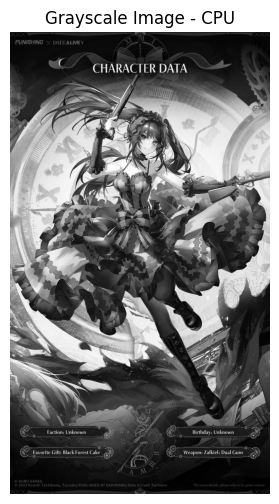



LABWORK 3 - 1D CUDA


Threads per block: 256
Blocks per grid: 8100
1D GPU time: 0.0006654262542724609 seconds
1D speedup: 2804.0286635614475 x


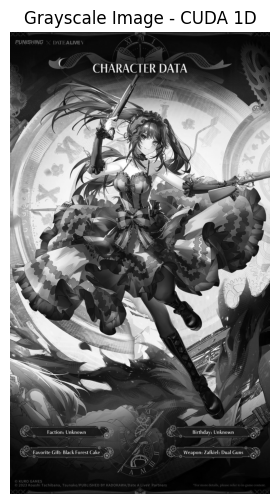



LABWORK 4 - 2D BLOCK EXPERIMENT


Block size:  4 x  4 | Threads/block:   16 | Grid:  270 x  480 | Time: 0.000790 s | Speedup: 2361.94x
Block size:  8 x  8 | Threads/block:   64 | Grid:  135 x  240 | Time: 0.000416 s | Speedup: 4482.27x
Block size: 16 x 16 | Threads/block:  256 | Grid:   68 x  120 | Time: 0.000399 s | Speedup: 4670.59x
Block size: 32 x  8 | Threads/block:  256 | Grid:   34 x  240 | Time: 0.000399 s | Speedup: 4679.53x
Block size:  8 x 32 | Threads/block:  256 | Grid:  135 x   60 | Time: 0.000400 s | Speedup: 4662.24x
Block size: 32 x 16 | Threads/block:  512 | Grid:   34 x  120 | Time: 0.000401 s | Speedup: 4657.25x


BEST 2D CONFIGURATION


Best block size: 32 x 8
Best GPU time: 0.00039873123168945315 seconds
Best 2D speedup: 4679.528820856254 x


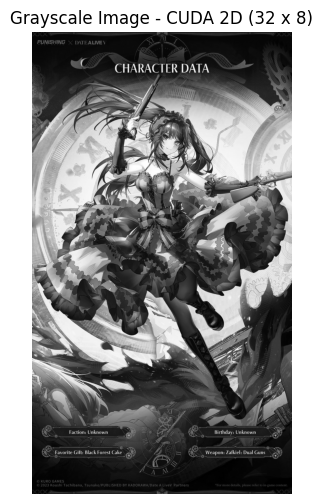



VALIDATION


1D maximum difference: 3.0517578e-05
1D mean difference: 2.53544e-06
2D maximum difference: 3.0517578e-05
2D mean difference: 2.53544e-06
1D validation: PASS
2D validation: PASS


FINAL PERFORMANCE COMPARISON


CPU time       : 1.865874 s
1D GPU time    : 0.000665 s
1D speedup     : 2804.03x
Best 2D GPU time: 0.000399 s
Best 2D speedup : 4679.53x
2D vs 1D GPU   : 1.67x


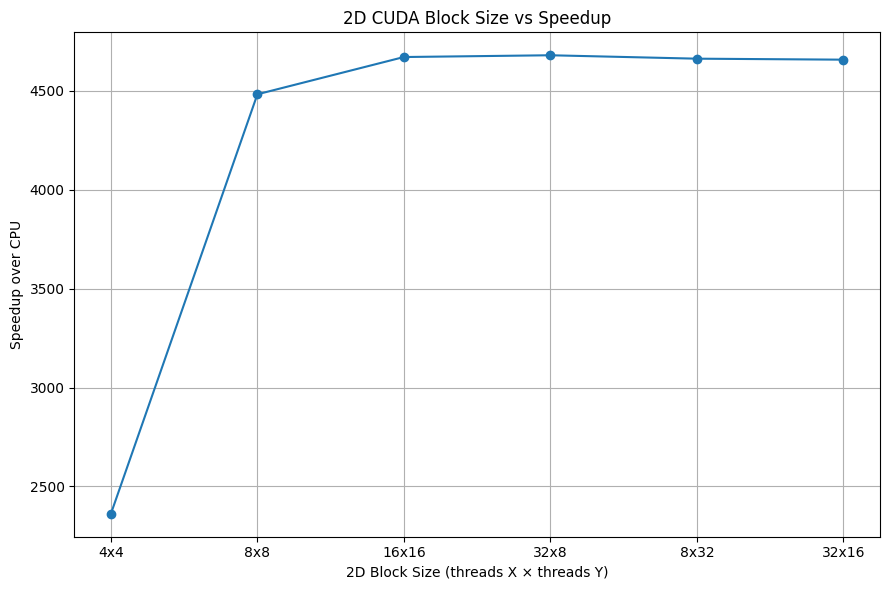

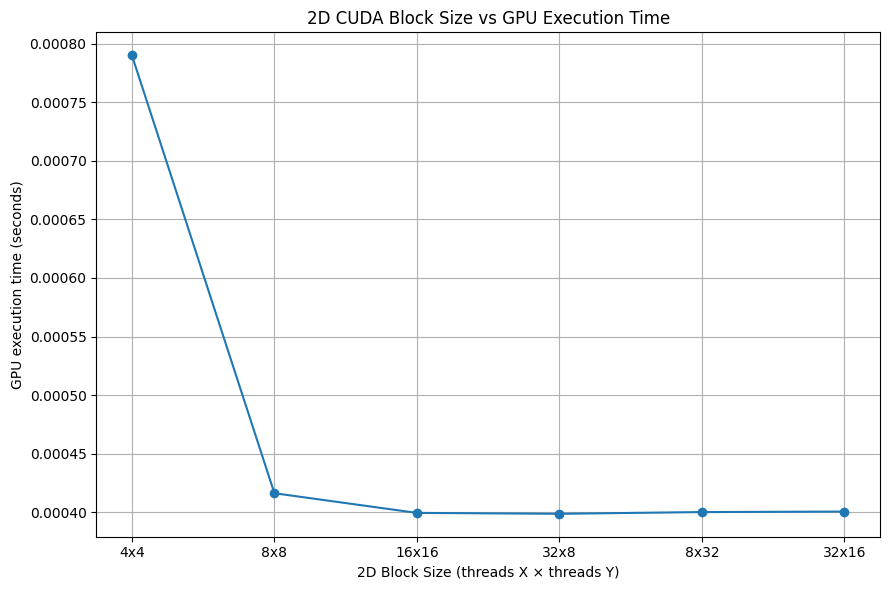

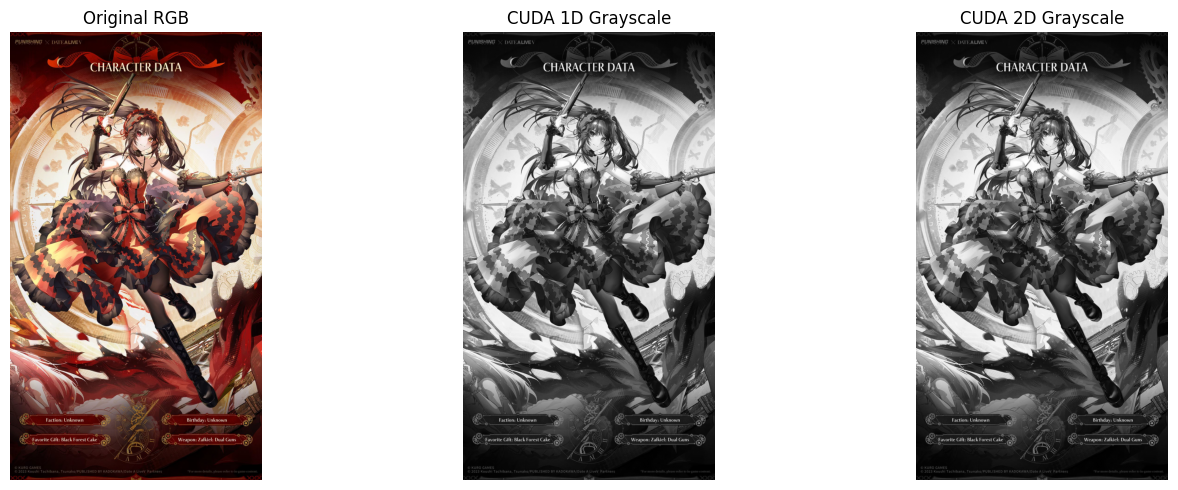



LABWORK 4 SUMMARY


Image size       : 1080 x 1920
Total pixels     : 2073600
CPU time         : 1.865874 s
1D GPU time      : 0.000665 s
1D speedup       : 2804.03x
Best 2D block    : 32 x 8
Best 2D GPU time : 0.000399 s
Best 2D speedup  : 4679.53x
2D / 1D speed   : 1.67x




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from numba import cuda
import time

# 1. LOAD IMAGE
image_path = "/content/img.jpg"

img = mpimg.imread(image_path)

print("Original image shape:", img.shape)
print("Original image dtype:", img.dtype)

# Remove alpha channel if the image is RGBA
if img.ndim == 3 and img.shape[2] == 4:
    img = img[:, :, :3]

# Convert to float32 for CUDA processing
img = img.astype(np.float32)

height, width, channels = img.shape
pixel_count = height * width

print("Image size:", width, "x", height)
print("Number of pixels:", pixel_count)
print("Channels:", channels)

# 2. FLATTEN IMAGE
#    Used by the original Labwork 3 1D implementation
rgb_pixels = img.reshape(pixel_count, 3)

print("Flattened RGB shape:", rgb_pixels.shape)

# 3. CPU GRAYSCALE
def grayscale_cpu(rgb):
    gray = np.empty(rgb.shape[0], dtype=np.float32)
    for i in range(rgb.shape[0]):
        r = rgb[i, 0]
        g = rgb[i, 1]
        b = rgb[i, 2]

        gray[i] = (
            0.299 * r +
            0.587 * g +
            0.114 * b
        )

    return gray


start_cpu = time.time()

gray_cpu = grayscale_cpu(rgb_pixels)

end_cpu = time.time()

cpu_time = end_cpu - start_cpu

gray_cpu_image = gray_cpu.reshape(height, width)

print("\nCPU grayscale time:", cpu_time, "seconds")

# Display CPU result
plt.figure(figsize=(8, 6))
plt.imshow(gray_cpu_image, cmap="gray")
plt.title("Grayscale Image - CPU")
plt.axis("off")
plt.show()

# Save CPU result
plt.imsave(
    "gray_cpu.jpg",
    gray_cpu_image,
    cmap="gray"
)

# 4. LABWORK 3 - 1D CUDA IMPLEMENTATION

@cuda.jit
def grayscale_gpu_1d(rgb, gray):
    # Global 1D thread index
    i = cuda.grid(1)

    # Make sure the thread does not access outside the array
    if i < rgb.shape[0]:
        r = rgb[i, 0]
        g = rgb[i, 1]
        b = rgb[i, 2]

        gray[i] = (
            0.299 * r +
            0.587 * g +
            0.114 * b
        )

# Copy input image to GPU
d_rgb = cuda.to_device(rgb_pixels)

# Allocate output array on GPU
d_gray_1d = cuda.device_array(
    pixel_count,
    dtype=np.float32
)

# Labwork 3 block configuration
threads_per_block_1d = 256

blocks_per_grid_1d = (
    pixel_count +
    threads_per_block_1d -
    1
) // threads_per_block_1d

print("\n")
print("LABWORK 3 - 1D CUDA")
print("\n")

print(
    "Threads per block:",
    threads_per_block_1d
)

print(
    "Blocks per grid:",
    blocks_per_grid_1d
)

# Warm-up
grayscale_gpu_1d[
    blocks_per_grid_1d,
    threads_per_block_1d
](d_rgb, d_gray_1d)

cuda.synchronize()

# Measure 1D GPU execution time
start_gpu_1d = time.time()

grayscale_gpu_1d[
    blocks_per_grid_1d,
    threads_per_block_1d
](d_rgb, d_gray_1d)

cuda.synchronize()

end_gpu_1d = time.time()

gpu_time_1d = end_gpu_1d - start_gpu_1d

# Copy result back to CPU
gray_1d = d_gray_1d.copy_to_host()

gray_1d_image = gray_1d.reshape(
    height,
    width
)

speedup_1d = cpu_time / gpu_time_1d

print("1D GPU time:", gpu_time_1d, "seconds")
print("1D speedup:", speedup_1d, "x")


# Display 1D result
plt.figure(figsize=(8, 6))
plt.imshow(gray_1d_image, cmap="gray")
plt.title("Grayscale Image - CUDA 1D")
plt.axis("off")
plt.show()

# Save 1D result
plt.imsave(
    "gray_gpu_1d.jpg",
    gray_1d_image,
    cmap="gray"
)

# 5. LABWORK 4 - 2D CUDA IMPLEMENTATION
@cuda.jit
def grayscale_gpu_2d(rgb_image, gray_image):
    # Get the 2D position of the current thread
    x, y = cuda.grid(2)

    # x = column
    # y = row

    if x < rgb_image.shape[1] and y < rgb_image.shape[0]:

        r = rgb_image[y, x, 0]
        g = rgb_image[y, x, 1]
        b = rgb_image[y, x, 2]

        gray_image[y, x] = (
            0.299 * r +
            0.587 * g +
            0.114 * b
        )

# 6. PREPARE IMAGE FOR 2D CUDA

# The 2D kernel uses:
#
#     rgb_image[y, x, channel]
#
# Therefore we keep the original 2D image structure.

d_rgb_2d = cuda.to_device(img)

d_gray_2d = cuda.device_array(
    (height, width),
    dtype=np.float32
)

# 7. FUNCTION TO RUN ONE 2D BLOCK CONFIGURATION
def measure_2d_block_size(
    block_x,
    block_y,
    repetitions=5
):

    # Calculate number of blocks required
    blocks_x = (
        width +
        block_x -
        1
    ) // block_x

    blocks_y = (
        height +
        block_y -
        1
    ) // block_y

    times = []

    # Run several times
    for _ in range(repetitions):
        start = time.time()

        grayscale_gpu_2d[
            (blocks_x, blocks_y),
            (block_x, block_y)
        ](
            d_rgb_2d,
            d_gray_2d
        )

        # Important:
        # CUDA kernel launches are asynchronous.
        # synchronize() makes sure the GPU has finished
        # before we stop the timer.
        cuda.synchronize()

        end = time.time()

        times.append(
            end - start
        )


    average_time = np.mean(times)

    return (
        average_time,
        blocks_x,
        blocks_y
    )

# 8. WARM-UP 2D CUDA
warmup_block_x = 16
warmup_block_y = 16

warmup_blocks_x = (
    width +
    warmup_block_x -
    1
) // warmup_block_x

warmup_blocks_y = (
    height +
    warmup_block_y -
    1
) // warmup_block_y


grayscale_gpu_2d[
    (warmup_blocks_x, warmup_blocks_y),
    (warmup_block_x, warmup_block_y)
](
    d_rgb_2d,
    d_gray_2d
)

cuda.synchronize()

# 9. EXPERIMENT WITH DIFFERENT 2D BLOCK SIZES

# Each tuple represents:
#
#     (threads in X direction,
#      threads in Y direction)
#
# Total threads:
#
#     block_x * block_y

block_sizes_2d = [
    (4, 4),
    (8, 8),
    (16, 16),
    (32, 8),
    (8, 32),
    (32, 16),
]

block_times_2d = []
speedups_2d = []

print("\n")
print("LABWORK 4 - 2D BLOCK EXPERIMENT")
print("\n")

for block_x, block_y in block_sizes_2d:
    average_time, blocks_x, blocks_y = (
        measure_2d_block_size(
            block_x,
            block_y,
            repetitions=5
        )
    )

    speedup = cpu_time / average_time

    block_times_2d.append(
        average_time
    )

    speedups_2d.append(
        speedup
    )

    total_threads = (
        block_x *
        block_y
    )

    print(
        f"Block size: "
        f"{block_x:2d} x {block_y:2d} "
        f"| Threads/block: {total_threads:4d} "
        f"| Grid: {blocks_x:4d} x {blocks_y:4d} "
        f"| Time: {average_time:.6f} s "
        f"| Speedup: {speedup:.2f}x"
    )

# 10. SELECT BEST MEASURED 2D CONFIGURATION
best_index = np.argmin(
    block_times_2d
)

best_block_x, best_block_y = (
    block_sizes_2d[best_index]
)

best_2d_time = (
    block_times_2d[best_index]
)

best_2d_speedup = (
    speedups_2d[best_index]
)


print("\n")
print("BEST 2D CONFIGURATION")
print("\n")

print(
    "Best block size:",
    best_block_x,
    "x",
    best_block_y
)

print(
    "Best GPU time:",
    best_2d_time,
    "seconds"
)

print(
    "Best 2D speedup:",
    best_2d_speedup,
    "x"
)

# 11. RUN BEST 2D CONFIGURATION AGAIN
best_blocks_x = (
    width +
    best_block_x -
    1
) // best_block_x

best_blocks_y = (
    height +
    best_block_y -
    1
) // best_block_y

grayscale_gpu_2d[
    (best_blocks_x, best_blocks_y),
    (best_block_x, best_block_y)
](
    d_rgb_2d,
    d_gray_2d
)

cuda.synchronize()

gray_2d_image = (
    d_gray_2d.copy_to_host()
)

# Save 2D result
plt.imsave(
    "gray_gpu_2d.jpg",
    gray_2d_image,
    cmap="gray"
)

# 12. DISPLAY 2D RESULT
plt.figure(figsize=(8, 6))

plt.imshow(
    gray_2d_image,
    cmap="gray"
)

plt.title(
    f"Grayscale Image - CUDA 2D "
    f"({best_block_x} x {best_block_y})"
)

plt.axis("off")

plt.show()

# 13. VALIDATION

difference_1d = np.abs(
    gray_cpu - gray_1d
)

difference_2d = np.abs(
    gray_cpu_image - gray_2d_image
)

max_difference_1d = np.max(
    difference_1d
)

mean_difference_1d = np.mean(
    difference_1d
)


max_difference_2d = np.max(
    difference_2d
)

mean_difference_2d = np.mean(
    difference_2d
)

print("\n")
print("VALIDATION")
print("\n")

print(
    "1D maximum difference:",
    max_difference_1d
)

print(
    "1D mean difference:",
    mean_difference_1d
)

print(
    "2D maximum difference:",
    max_difference_2d
)

print(
    "2D mean difference:",
    mean_difference_2d
)

if np.allclose(
    gray_cpu,
    gray_1d,
    atol=1e-5
):

    print(
        "1D validation: PASS"
    )

else:

    print(
        "1D validation: FAIL"
    )


if np.allclose(
    gray_cpu_image,
    gray_2d_image,
    atol=1e-5
):

    print(
        "2D validation: PASS"
    )

else:

    print(
        "2D validation: FAIL"
    )

# 14. FINAL PERFORMANCE COMPARISON
print("\n")
print("FINAL PERFORMANCE COMPARISON")
print("\n")

print(
    f"CPU time       : {cpu_time:.6f} s"
)

print(
    f"1D GPU time    : {gpu_time_1d:.6f} s"
)

print(
    f"1D speedup     : {speedup_1d:.2f}x"
)

print(
    f"Best 2D GPU time: {best_2d_time:.6f} s"
)

print(
    f"Best 2D speedup : {best_2d_speedup:.2f}x"
)

# Compare 2D directly with the previous 1D GPU
gpu_2d_vs_1d_speedup = (
    gpu_time_1d /
    best_2d_time
)

print(
    f"2D vs 1D GPU   : "
    f"{gpu_2d_vs_1d_speedup:.2f}x"
)

# 15. GRAPH: 2D BLOCK SIZE VS SPEEDUP

# Convert tuples into readable labels
block_labels = [
    f"{x}x{y}"
    for x, y in block_sizes_2d
]

plt.figure(figsize=(9, 6))

plt.plot(
    block_labels,
    speedups_2d,
    marker="o"
)

plt.xlabel(
    "2D Block Size (threads X × threads Y)"
)

plt.ylabel("Speedup over CPU")

plt.title("2D CUDA Block Size vs Speedup")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/block_size_2d_vs_speedup.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 16. GRAPH: 2D BLOCK SIZE VS EXECUTION TIME
#    Useful for additional analysis

plt.figure(figsize=(9, 6))

plt.plot(
    block_labels,
    block_times_2d,
    marker="o"
)

plt.xlabel(
    "2D Block Size (threads X × threads Y)"
)

plt.ylabel(
    "GPU execution time (seconds)"
)

plt.title(
    "2D CUDA Block Size vs GPU Execution Time"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "/content/block_size_2d_vs_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 17. FINAL VISUAL COMPARISON
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)

plt.imshow(
    img.astype(np.uint8)
)

plt.title(
    "Original RGB"
)

plt.axis("off")

plt.subplot(1, 3, 2)

plt.imshow(
    gray_1d_image,
    cmap="gray"
)

plt.title(
    "CUDA 1D Grayscale"
)

plt.axis("off")

plt.subplot(1, 3, 3)

plt.imshow(
    gray_2d_image,
    cmap="gray"
)

plt.title(
    "CUDA 2D Grayscale"
)

plt.axis("off")

plt.tight_layout()

plt.show()

# 18. FINAL SUMMARY

print("\n")
print("LABWORK 4 SUMMARY")
print("\n")

print(
    f"Image size       : {width} x {height}"
)

print(
    f"Total pixels     : {pixel_count}"
)

print(
    f"CPU time         : {cpu_time:.6f} s"
)

print(
    f"1D GPU time      : {gpu_time_1d:.6f} s"
)

print(
    f"1D speedup       : {speedup_1d:.2f}x"
)

print(
    f"Best 2D block    : "
    f"{best_block_x} x {best_block_y}"
)

print(
    f"Best 2D GPU time : "
    f"{best_2d_time:.6f} s"
)

print(
    f"Best 2D speedup  : "
    f"{best_2d_speedup:.2f}x"
)

print(
    f"2D / 1D speed   : "
    f"{gpu_2d_vs_1d_speedup:.2f}x"
)

print("\n")